# Time Averaging of 1-min Data (floor / ceiling / center)
# 分钟级数据时间平均（floor / ceiling / center）

This notebook loads BSRN station-to-archive data, builds REST2 clear-sky references (MERRA-2 inputs via Hugging Face), adds solar geometry, runs the QC suite, then applies **`pretty_average`** for temporal averaging.

**§6** explains how `pretty_average` differs from `pandas.resample` (windows, monthly label trim, coverage, `match_ceiling_labels`); **§6.1** uses **`df_qc`** for alignments; **§6.2** compares **`match_ceiling_labels`** for **center** only; **§6.3** tabulates **samples per 1 h interval** (floor / ceiling / center). **§7** applies 1 h averaging to the QIQ month. **§8–9** plot comparisons (plots at the end of the workflow).

本笔记本加载 BSRN 站点存档数据，基于 Hugging Face 上的 MERRA-2 输入构建 REST2 晴空参考，加入太阳几何，运行 QC，再用 **`pretty_average`** 做时间平均。

**§6** 说明差异（窗、月界裁剪、覆盖、`match_ceiling_labels`）；**§6.1** 用 **`df_qc`** 比较对齐方式；**§6.2** 仅比较 **center** 的 **`match_ceiling_labels`**；**§6.3** 统计每个 1h 窗的**样本数**（floor / ceiling / center）。**§7** 对 QIQ 全月做 1 小时平均。**§8–9** 为对比图（图放在工作流末尾）。


## 1. Import libraries / 导入库

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd

import bsrn
from bsrn.physics import geometry
from bsrn.utils import pretty_average

# Same sample file pattern as 4.clear_sky_detection.ipynb
INPUT_FILE = "/Volumes/Macintosh Research/Data/bsrn-qc/data/QIQ/qiq0824.dat.gz"

pd.options.display.max_columns = None
%matplotlib inline

## 2. Load QIQ August data / 加载 QIQ 8 月数据

In [2]:
stn = os.path.basename(INPUT_FILE).split(".")[0][:3].upper()

if os.path.exists(INPUT_FILE):
    df = bsrn.io.readers.read_station_to_archive(INPUT_FILE, logical_records="lr0100")
    print(f"Data for {stn} loaded successfully (August 2024).")
    display(df.head())
else:
    raise FileNotFoundError(
        f"File not found: {INPUT_FILE}. Current working directory: {os.getcwd()}"
    )

Data for QIQ loaded successfully (August 2024).


,ghi,bni,dhi,lwd,temp,rh,pressure
time,,,,,,,
2024-08-01 00:00:00+00:00,105.0,0.0,106.0,421.0,25.2,70.0,981.0
2024-08-01 00:01:00+00:00,108.0,0.0,109.0,422.0,25.2,71.0,981.0
2024-08-01 00:02:00+00:00,112.0,0.0,113.0,421.0,25.2,70.0,981.0
2024-08-01 00:03:00+00:00,113.0,0.0,114.0,421.0,25.2,70.0,981.0
2024-08-01 00:04:00+00:00,116.0,0.0,117.0,421.0,25.2,71.0,981.0


## 3. Solar positioning / 太阳几何角

Clear-sky modeling strictly requires precise solar geometry columns (`zenith`, `apparent_zenith`, [bni_extra](cci:1://file:///Volumes/Macintosh%20Research/Data/bsrn-qc/src/bsrn/physics/geometry.py:123:0-160:44)). We must explicitly call **[add_solpos_columns](cci:1://file:///Volumes/Macintosh%20Research/Data/bsrn-qc/src/bsrn/physics/geometry.py:188:0-270:13)** on our high-frequency data (1-5 min) *before* any modeling or time averaging occurs to prevent non-linear errors.

晴空模型严格依赖高精度的太阳几何列（`zenith`、`apparent_zenith`、[bni_extra](cci:1://file:///Volumes/Macintosh%20Research/Data/bsrn-qc/src/bsrn/physics/geometry.py:123:0-160:44)）。我们在任何建模或时间平均之前，必须在原始高频数据（1-5 分钟）上调用 **`add_solpos_columns`** 显式计算几何位置，以避免非线性的聚合误差。



In [3]:
df = geometry.add_solpos_columns(df, station_code=stn)

display(df[["ghi", "zenith"]].head())

,ghi,zenith
time,,
2024-08-01 00:00:00+00:00,105.0,54.880866
2024-08-01 00:01:00+00:00,108.0,54.717032
2024-08-01 00:02:00+00:00,112.0,54.553333
2024-08-01 00:03:00+00:00,113.0,54.389772
2024-08-01 00:04:00+00:00,116.0,54.226351


## 4. Clear-sky modeling with REST2 / 使用 REST2 晴空建模

`model='rest2'` pulls **REST2-ready** columns (PS, ALBEDO, …) from the MERRA-2 parquet asset on Hugging Face (`huggingface_hub`). The first run may download data; ensure network access.



### 4.1 Run `add_clearsky_columns` / 运行 `add_clearsky_columns`

The input is **`df`** from **§3** — the **August** station-to-archive slice (e.g. QIQ `qiq0824.dat.gz`) with solpose information. REST2 resolves MERRA-2 columns from Hugging Face, then computes **`ghi_clear`**, **`bni_clear`**, **`dhi_clear`** (and longwave clears if applicable) on the **same** `DatetimeIndex` as that archive.

输入为 **§2** 中的 **`df`**（如 QIQ **`qiq0824.dat.gz`** 的 **八月** 站点存档）。REST2 从 Hugging Face 取 MERRA-2 列，并在与存档**相同**的时间索引上计算 **`ghi_clear`**、**`bni_clear`**、**`dhi_clear`**（及适用的长波晴空列）。


In [4]:
df_cs = bsrn.modeling.clear_sky.add_clearsky_columns(
    df.copy(),
    station_code=stn,
    model="rest2",
)

display(df_cs[["ghi", "ghi_clear", "bni", "bni_clear", "dhi", "dhi_clear"]].head())

Fetching MERRA-2 from Hugging Face: qiq/qiq0824_merra2.parquet


,ghi,ghi_clear,bni,bni_clear,dhi,dhi_clear
time,,,,,,
2024-08-01 00:00:00+00:00,105.0,507.441901,0.0,664.499868,106.0,125.169454
2024-08-01 00:01:00+00:00,108.0,509.994389,0.0,665.752878,109.0,125.445544
2024-08-01 00:02:00+00:00,112.0,512.540813,0.0,666.996098,113.0,125.719827
2024-08-01 00:03:00+00:00,113.0,515.081104,0.0,668.229606,114.0,125.992312
2024-08-01 00:04:00+00:00,116.0,517.615195,0.0,669.453478,117.0,126.263009


### 4.2 Measured vs clear-sky columns / 实测列与晴空列

**`ghi`**, **`bni`**, **`dhi`** are measurements; **`*_clear`** are the REST2 clear-sky references at the same timestamps. Use them later for QC flags and clear-sky index–style diagnostics.

**`ghi`**、**`bni`**、**`dhi`** 为实测；**`*_clear`** 为相同时刻的 REST2 晴空参考，供后续 QC 与晴空指数等诊断使用。


## 5. Run QC wrapper / 运行 QC 包装函数

`run_qc` adds flag columns (0 = pass, 1 = fail). See `4.clear_sky_detection.ipynb` for a full table of tests.

`run_qc` 会添加标记列（0 = 通过，1 = 失败）。完整测试说明见 `4.clear_sky_detection.ipynb`。

In [5]:
df_qc = bsrn.qc.run_qc(df.copy(), station_code=stn)

flag_cols = [c for c in df_qc.columns if c.startswith("flag")]
print("QC flag counts (non-zero = fail) / 标记计数（非零 = 失败）：")
display(df_qc[flag_cols].sum())


QC flag counts (non-zero = fail) / 标记计数（非零 = 失败）：


flagPPLGHI        180
flagPPLBNI        180
flagPPLDHI        180
flagPPLLWD        180
flagERLGHI      10283
flagERLBNI        190
flagERLDHI      11286
flagERLLWD        180
flag3lowSZA         0
flag3highSZA        0
flagKKt            17
flagKlowSZA         3
flagKhighSZA        0
flagKbKt            0
flagKb              0
flagKt              0
flagTracker        24
dtype: int64

## 6. What `pretty_average` does / `pretty_average` 的语义

`bsrn.utils.averaging.pretty_average` implements **explicit labeled windows** — it is **not**
`pandas.DataFrame.resample`. For each output label time `L` (bin length `Δ` from `rule`), data rows are selected with a rule that depends on **`alignment`**.

`pretty_average` 使用**显式标签窗**，**不是** `resample`。对每个输出标签时刻 `L`（`rule` 给出窗长 `Δ`），按 **`alignment`** 选取行。

### Windows / 窗定义

| Alignment | Interval | Role of `L` |
| :--- | :--- | :--- |
| **floor** | $[L, L+\Delta)$ | Label at **left** edge / 标签在左端 |
| **ceiling** | $(L-\Delta, L]$ | Label at **right** edge / 标签在右端 |
| **center** | $[L-\Delta/2+\mathrm{res},\, L+\Delta/2]$ | Label at **center**; `res` = native step (1 or 3 min inferred for LR0100 if omitted) / 标签居中；`res` 为原生步长（LR0100 可省略，由索引推断 1 或 3 分钟） |

### Monthly label trim / 月界标签裁剪

The regular grid from `floor(min)` … `ceil(max)` at `rule` is **trimmed** so edge bins do not straddle month boundaries (`lo` / `hi` from the data index). **floor** drops labels at the high edge; **ceiling** drops at the low edge. For **center**, choose the same trim as **ceiling** or **floor** via **`match_ceiling_labels`** (default `True`).

规则网格会**裁剪**，避免边界小时跨月。**center** 与 ceiling 或 floor **共用**哪一套裁剪由 **`match_ceiling_labels`** 控制（默认与 ceiling 一致）。

### Coverage / 覆盖

A numeric aggregate is emitted only if enough rows are “valid” (numeric columns: at least one finite value in that row).

- **floor / ceiling:** valid count must be **>** half of the nominal step count $\approx \Delta/\mathrm{res}$.
- **center:** valid count must be **>** half of **rows in the window** (not the nominal count).

Otherwise the row is still emitted but values are **NaN**.

### Inputs / 输入

- **`DatetimeIndex`** is required.\n

**Below:** **§6.1** uses **`df_qc`** for floor/ceiling/center; **§6.2** compares **`match_ceiling_labels`** (center only); **§6.3** counts **samples per 1 h** window. **§7** applies `pretty_average` for the workflow plots.

**下方：****§6.1** 用 **`df_qc`** 比较 floor/ceiling/center；**§6.2** 比较 **`match_ceiling_labels`**（仅 center）；**§6.3** 统计每 1h 窗**样本数**；**§7** 为工作流整月应用。


### 6.1 Case A — full month, different label times / 整月、不同标签时刻

**All rows** in **`df_qc`** (one station-month from the archive). `rule='1h'`: **floor** / **ceiling** / **center** differ in where the hour label sits; counts can differ slightly at month edges.

**整表** **`df_qc`**（存档中的单站单月）。`rule='1h'`：**floor** / **ceiling** / **center** 的标签时刻不同；月界附近行数可略有差异。


In [6]:
# df_qc already spans one station-month (see INPUT_FILE). / df_qc 已覆盖单站单月（见 INPUT_FILE）
df_a = df_qc[["ghi", "zenith"]].copy()
rule = "1h"

f_a = pretty_average(df_a, rule, alignment="floor")
c_a = pretty_average(df_a, rule, alignment="ceiling")
z_a = pretty_average(df_a, rule, alignment="center")

print("Case A — 1 h labels (UTC) on the loaded month:")
print(f"  native rows in window: {len(df_a)}")
for name, s in [("floor", f_a), ("ceiling", c_a), ("center", z_a)]:
    print(f"  {name:7s}: n={len(s):4d}  first={s.index[0]}  last={s.index[-1]}")


Case A — 1 h labels (UTC) on the loaded month:
  native rows in window: 44640
  floor  : n= 744  first=2024-08-01 00:00:00+00:00  last=2024-08-31 23:00:00+00:00
  ceiling: n= 744  first=2024-08-01 01:00:00+00:00  last=2024-09-01 00:00:00+00:00
  center : n= 744  first=2024-08-01 01:00:00+00:00  last=2024-09-01 00:00:00+00:00


### 6.2 Case B — `match_ceiling_labels` usage / `match_ceiling_labels` 用法

For **`alignment='center'`** only: **`match_ceiling_labels`** chooses whether monthly label trimming follows **ceiling** (default) or **floor**. Compare the two **`center`** outputs (row counts and first/last labels).

仅 **`alignment='center'`**：**`match_ceiling_labels`** 决定月界裁剪与 **ceiling** 还是 **floor** 一致（默认 True）。比较两种 **`center`** 结果（行数与首尾标签）。


In [7]:
rule = "1h"
# Same input columns as §6.1; Case B only compares center + match_ceiling_labels / 与 §6.1 同列；本节只比较 center 与 match_ceiling_labels
df_b = df_qc[["ghi", "zenith"]].copy()

z_hi = pretty_average(df_b, rule, alignment="center", match_ceiling_labels=True)
z_lo = pretty_average(df_b, rule, alignment="center", match_ceiling_labels=False)

print("Case B — center only: match_ceiling_labels True vs False")
print(f"  n_row: {len(z_hi)} vs {len(z_lo)}")
print("  first label:", z_hi.index[0], "vs", z_lo.index[0])
print("  last  label:", z_hi.index[-1], "vs", z_lo.index[-1])


Case B — center only: match_ceiling_labels True vs False
  n_row: 744 vs 744
  first label: 2024-08-01 01:00:00+00:00 vs 2024-08-01 00:00:00+00:00
  last  label: 2024-09-01 00:00:00+00:00 vs 2024-08-31 23:00:00+00:00


### 6.3 Case C — samples per 1 h interval / 每个 1 小时窗内样本数

For **`rule='1h'`**, each output row is the mean over a **time window**; the table counts **how many native rows** fall in that window (**`n_samples`**) for **floor**, **ceiling**, and **center** (same logic as `pretty_average`). Labels and counts **differ** across alignments.

**`rule='1h'`** 下，每个输出标签对应一个**时间窗**；下表统计窗内**原生行数**（**`n_samples`**），分别对应 **floor**、**ceiling**、**center**（与 `pretty_average` 一致）。不同对齐的**标签时刻**与**行数**可不同。


In [8]:
import bsrn.utils.averaging as av

def hourly_sample_counts(df, rule, alignment, match_ceiling_labels=True):
    """Native rows per 1 h label (same windows as pretty_average). / 与 pretty_average 相同的窗内行数"""
    delta = av._period_delta(rule)
    res = av._archive_timestep_1_or_3(df.index)
    labels = av._label_grid(df.index, rule)
    labels = av._trim_labels_for_alignment(
        labels, df.index, rule, alignment, match_ceiling_labels=match_ceiling_labels,
    )
    idx = df.index
    rows = []
    for L in labels:
        m = av._window_mask(idx, L, delta, alignment, res)
        rows.append((L, int(m.sum())))
    return pd.DataFrame(rows, columns=["label_utc", "n_samples"])


rule = "1h"
dfc = df_qc[["ghi", "zenith"]].copy()

floor_ct = hourly_sample_counts(dfc, rule, "floor")
ceil_ct = hourly_sample_counts(dfc, rule, "ceiling")
cent_ct = hourly_sample_counts(dfc, rule, "center", match_ceiling_labels=True)

print("Case C — n_samples per 1 h interval (native rows in each window)")
print("\nfloor — head 4 / 前 4:")
print(floor_ct.head(4).to_string(index=False))
print("floor — tail 4 / 後 4:")
print(floor_ct.tail(4).to_string(index=False))
print("\nceiling — head 4 / 前 4:")
print(ceil_ct.head(4).to_string(index=False))
print("ceiling — tail 4 / 後 4:")
print(ceil_ct.tail(4).to_string(index=False))
print("\ncenter (match_ceiling_labels=True) — head 4 / 前 4:")
print(cent_ct.head(4).to_string(index=False))
print("center — tail 4 / 後 4:")
print(cent_ct.tail(4).to_string(index=False))

print("\nSummary n_samples (all intervals / 全部区间):")
for name, tab in [("floor", floor_ct), ("ceiling", ceil_ct), ("center", cent_ct)]:
    s = tab["n_samples"]
    print(f"  {name:7s}: count={len(s)}, min={s.min()}, max={s.max()}, mean={s.mean():.1f}")


Case C — n_samples per 1 h interval (native rows in each window)

floor — head 4 / 前 4:
                label_utc  n_samples
2024-08-01 00:00:00+00:00         60
2024-08-01 01:00:00+00:00         60
2024-08-01 02:00:00+00:00         60
2024-08-01 03:00:00+00:00         60
floor — tail 4 / 後 4:
                label_utc  n_samples
2024-08-31 20:00:00+00:00         60
2024-08-31 21:00:00+00:00         60
2024-08-31 22:00:00+00:00         60
2024-08-31 23:00:00+00:00         60

ceiling — head 4 / 前 4:
                label_utc  n_samples
2024-08-01 01:00:00+00:00         60
2024-08-01 02:00:00+00:00         60
2024-08-01 03:00:00+00:00         60
2024-08-01 04:00:00+00:00         60
ceiling — tail 4 / 後 4:
                label_utc  n_samples
2024-08-31 21:00:00+00:00         60
2024-08-31 22:00:00+00:00         60
2024-08-31 23:00:00+00:00         60
2024-09-01 00:00:00+00:00         59

center (match_ceiling_labels=True) — head 4 / 前 4:
                label_utc  n_samples
2024-08-01 0

## 7. Apply to QIQ (1 h) / 应用到 QIQ（1 小时）

Same `rule` and three alignments on the QC’d August frame. Row counts often differ slightly between alignments.

在 QC 后的 8 月数据上使用相同 `rule` 与三种对齐；不同对齐下行数可能略有差异。


In [9]:
RULE = "1h"

# Irradiance + zenith (required by pretty_average)
cols_avg = [c for c in ("ghi", "ghi_clear", "zenith") if c in df_qc.columns]
df_in = df_qc[cols_avg].copy()

avg_floor = pretty_average(df_in, RULE, alignment="floor")
avg_ceil = pretty_average(df_in, RULE, alignment="ceiling")
avg_center = pretty_average(df_in, RULE, alignment="center")

print("Row counts — floor:", len(avg_floor), "ceiling:", len(avg_ceil), "center:", len(avg_center))


Row counts — floor: 744 ceiling: 744 center: 744


## 8. Plots: compare GHI means / 图：比较 GHI 平均

Run **§7** first so `avg_floor`, `avg_ceil`, and `avg_center` exist.

先运行 **§7**，以生成 `avg_floor`、`avg_ceil`、`avg_center`。

Overlay 1-hour mean **GHI** for the three alignments on a short slice (2024-08-08 UTC).

在一天片段上叠加三种对齐的 1 小时平均 **GHI**。


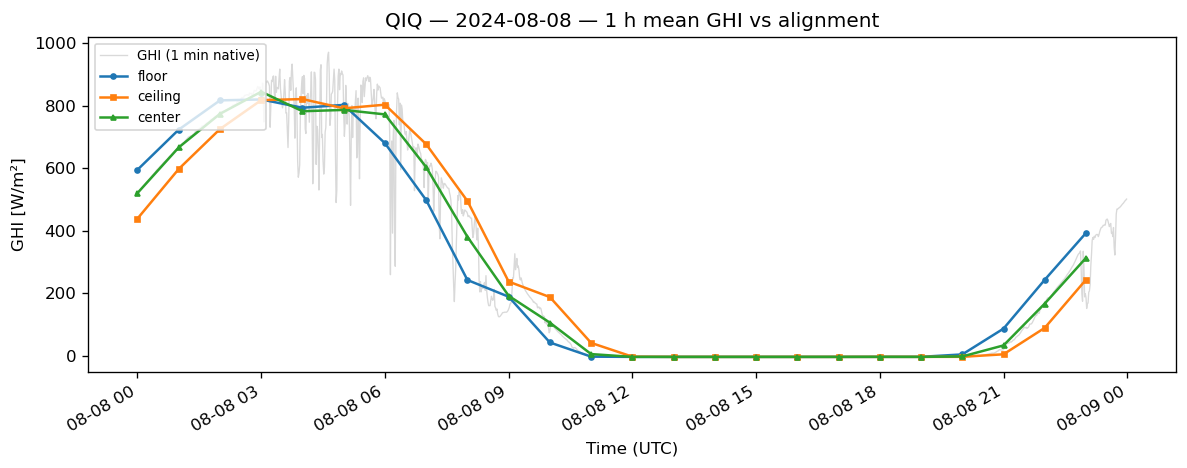

In [10]:
day = "2024-08-08"
sub = slice(f"{day} 00:00", f"{day} 23:59")

fig, ax = plt.subplots(figsize=(10, 4), dpi=120)

if "ghi" in df_qc.columns:
    ax.plot(
        df_qc.loc[sub].index,
        df_qc.loc[sub, "ghi"],
        color="0.85",
        linewidth=0.8,
        label="GHI (1 min native)",
    )

ax.plot(avg_floor.loc[sub].index, avg_floor.loc[sub, "ghi"], marker="o", markersize=3, label="floor")
ax.plot(avg_ceil.loc[sub].index, avg_ceil.loc[sub, "ghi"], marker="s", markersize=3, label="ceiling")
ax.plot(avg_center.loc[sub].index, avg_center.loc[sub, "ghi"], marker="^", markersize=3, label="center")

ax.set_ylabel("GHI [W/m²]")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"{stn} — {day} — 1 h mean GHI vs alignment")
ax.legend(loc="upper left", fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 9. Optional: compare clear-sky GHI / 可选：比较晴空 GHI

Same overlay for **`ghi_clear`** (REST2).

对 **`ghi_clear`**（REST2）做同样叠加。


In [11]:
if "ghi_clear" in avg_floor.columns:
    fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
    ax.plot(avg_floor.loc[sub].index, avg_floor.loc[sub, "ghi_clear"], marker="o", markersize=3, label="floor")
    ax.plot(avg_ceil.loc[sub].index, avg_ceil.loc[sub, "ghi_clear"], marker="s", markersize=3, label="ceiling")
    ax.plot(avg_center.loc[sub].index, avg_center.loc[sub, "ghi_clear"], marker="^", markersize=3, label="center")
    ax.set_ylabel("GHI clear [W/m²]")
    ax.set_xlabel("Time (UTC)")
    ax.set_title(f"{stn} — {day} — REST2 ghi_clear (1 h)")
    ax.legend(loc="upper left", fontsize=8)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()